## Temperatura media mensile a Sydney

**Obiettivo**: analizzare e prevedere l'andamento nel tempo della temperatura pomeridiana (`Temp3pm`)
di **una singola località** (Sydney), aggregata su base **mensile**.

**Pipeline dell'analisi**
1. Preparazione della serie (filtro località, aggregazione mensile, gestione NaN)
2. Analisi esplorativa e decomposizione (trend / stagionalità / residuo)
3. Test di stazionarietà (ADF e KPSS) e differenziazione
4. Identificazione degli ordini con ACF e PACF
5. Modellazione: SARIMAX manuale + auto-ARIMA + esogene
6. Validazione, forecast e metriche di errore (MAE, RMSE, MAPE)
7. Diagnostica dei residui
8. Previsione futura

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

In [25]:
def load_dataset(filename="weatherAUS.csv", cartella="dataset"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        file = base / cartella / filename
        if file.exists():
            return file
    raise FileNotFoundError(
        f"'{cartella}/{filename}' non trovato. Scarica il dataset da Kaggle "
        f"e mettilo nella cartella '{cartella}/' nella root del progetto."
    )

DATA_PATH = load_dataset()
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], na_values="NA")

## Preparazione della serie

In [26]:
LOCALITA = "Sydney"
VARIABILE = "Temp3pm"
N_TEST    = 24          # mesi tenuti da parte per la validazione (2 anni)

# gestione della deprecazione pandas "M" -> "ME"
FREQ = "ME"
try:
    pd.Series(dtype=float, index=pd.DatetimeIndex([])).resample(FREQ)
except ValueError:
    FREQ = "M"

# Estrae la serie giornaliera per la località scelta e la ordina in base alla data usata come indice
serie_giorn = df[df["Location"] == LOCALITA].set_index("Date")[VARIABILE].sort_index()
# Calcola la media mensile della variabile
serie = serie_giorn.resample(FREQ).mean()

print(f"{LOCALITA} | {VARIABILE}")
print("Periodo:", serie.index.min().date(), "->", serie.index.max().date())
print("Mesi totali:", len(serie), "| mesi mancanti:", int(serie.isna().sum()))
print("Mesi mancanti:", [d.strftime('%Y-%m') for d in serie[serie.isna()].index])

Sydney | Temp3pm
Periodo: 2008-02-29 -> 2017-06-30
Mesi totali: 113 | mesi mancanti: 3
Mesi mancanti: ['2011-04', '2012-12', '2013-02']


In [27]:
# Imputazione dei mesi mancanti
mesi_mancanti = serie[serie.isna()].index
soglia_test   = serie.index[-N_TEST]
assert (mesi_mancanti < soglia_test).all(), \
    "Ci sono NaN nel periodo di test: l'interpolazione introdurrebbe lookahead."

# Interpolo SOLO la parte train: nessun valore del periodo di test può influire sull'imputazione 
serie_train_imp = serie.iloc[:-N_TEST].interpolate(method="time")
serie = pd.concat([serie_train_imp, serie.iloc[-N_TEST:]])

print("Dopo interpolazione -> NaN:", int(serie.isna().sum()))
print(f"Temperatura: min={serie.min():.1f}C  max={serie.max():.1f}C  media={serie.mean():.1f}C")
serie.head()

Dopo interpolazione -> NaN: 0
Temperatura: min=16.1C  max=27.3C  media=21.6C


Date
2008-02-29    23.203448
2008-03-31    24.077419
2008-04-30    20.363333
2008-05-31    19.461290
2008-06-30    17.820000
Freq: ME, Name: Temp3pm, dtype: float64

## Analisi esplorativa della serie

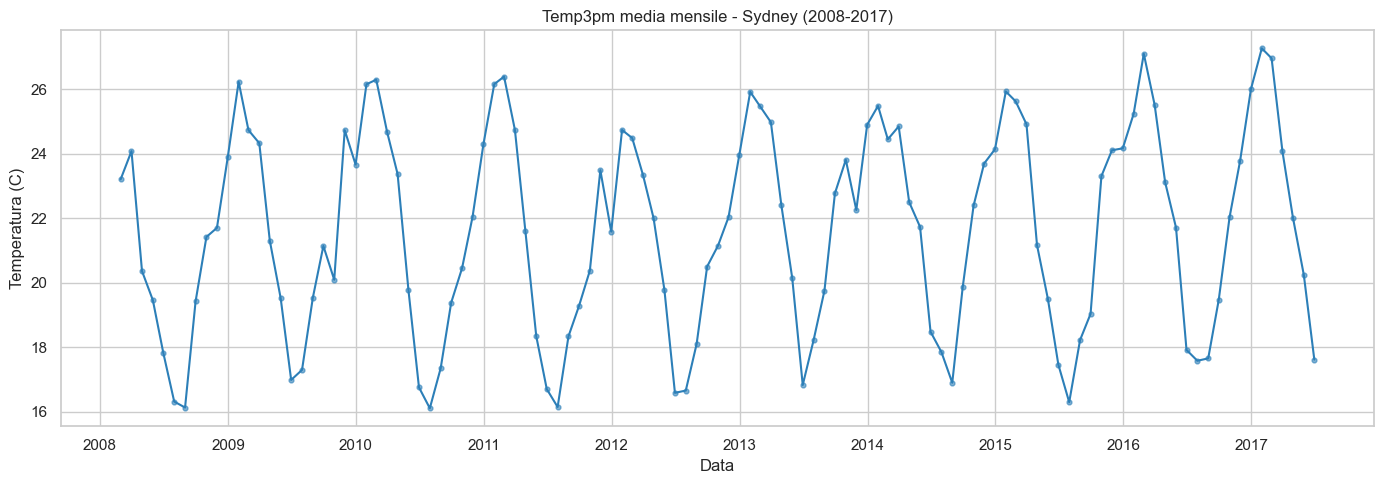

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(serie.index, serie.values, color="#2C7FB8", lw=1.5)
plt.scatter(serie.index, serie.values, s=12, color="#2C7FB8", alpha=.6)
plt.title(f"{VARIABILE} media mensile - {LOCALITA} ({serie.index.min().year}-{serie.index.max().year})")
plt.xlabel("Data")
plt.ylabel("Temperatura (C)")
plt.tight_layout()
plt.show()

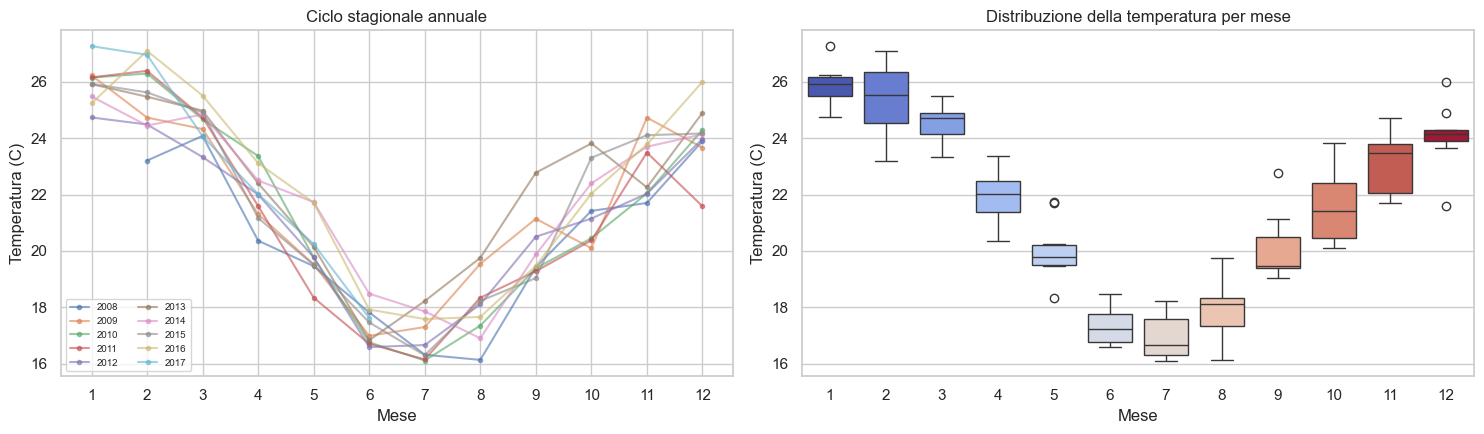

In [29]:
# La stagionalita' vista sovrapponendo gli anni uno sull'altro
tmp = pd.DataFrame({"valore": serie.values}, index=serie.index)
tmp["anno"] = tmp.index.year
tmp["mese"] = tmp.index.month

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
# grafico a linee: sovrapposizione di ciascun anno
for anno, g in tmp.groupby("anno"):
    axes[0].plot(g["mese"], g["valore"], marker="o", ms=3, alpha=.6, label=str(anno))
axes[0].set_title("Ciclo stagionale annuale")
axes[0].set_xlabel("Mese"); axes[0].set_ylabel("Temperatura (C)")
axes[0].set_xticks(range(1, 13)); axes[0].legend(fontsize=7, ncol=2)

# Variabilità e distribuzione mensile delle temperature
sns.boxplot(data=tmp, x="mese", y="valore", hue="mese", palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].set_title("Distribuzione della temperatura per mese")
axes[1].set_xlabel("Mese"); axes[1].set_ylabel("Temperatura (C)")
plt.tight_layout()
plt.show()

### Decomposizione della serie

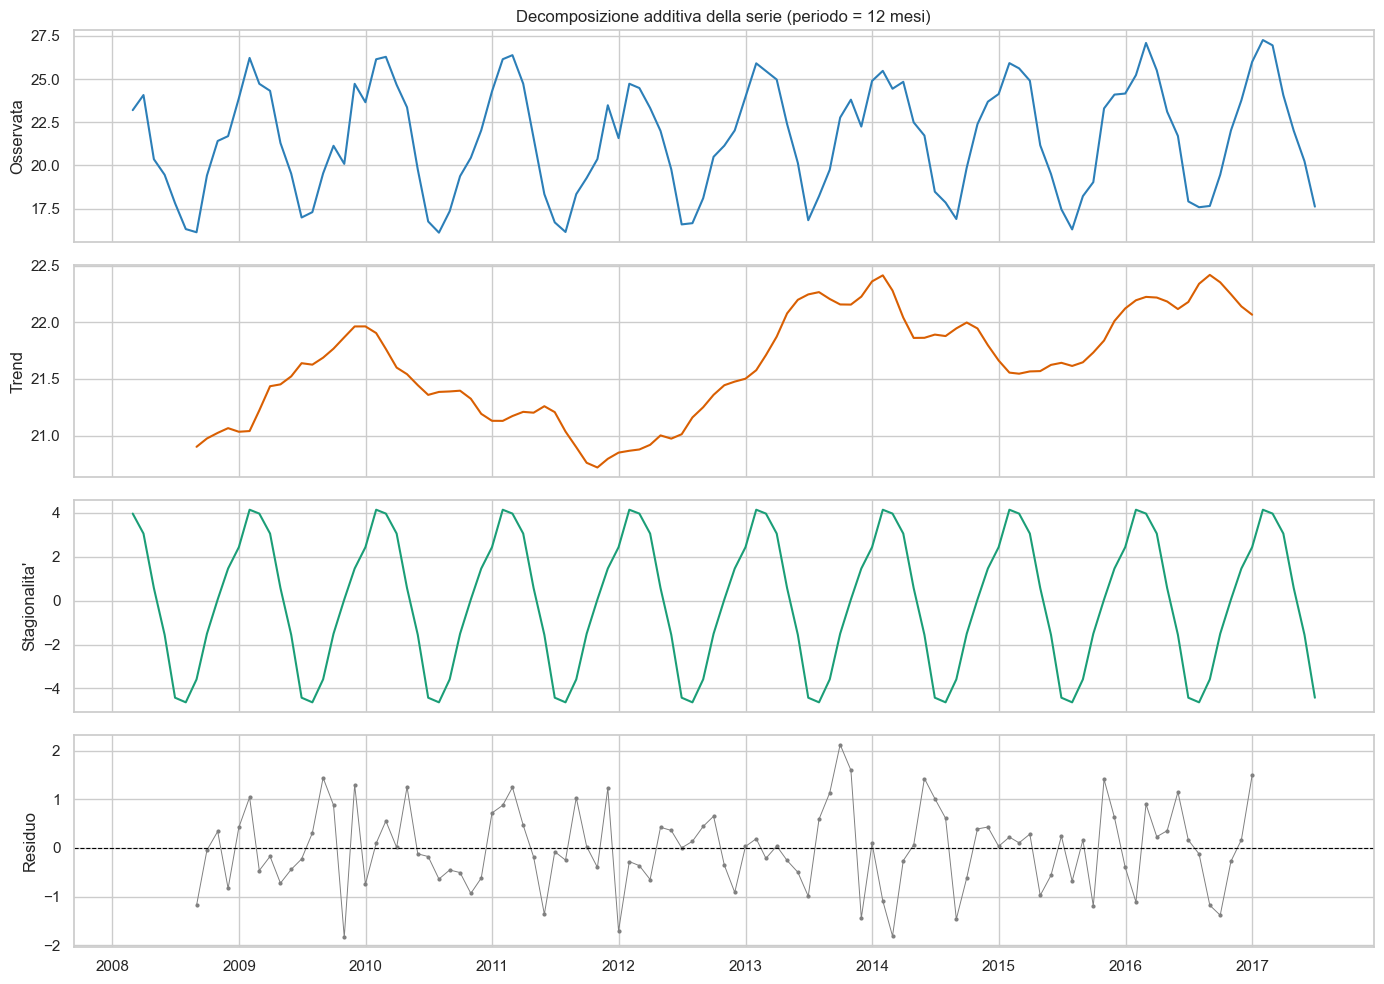

Ampiezza del ciclo stagionale: 8.8 C
Deviazione standard del residuo: 0.83 C


In [30]:
# Scompone la serie in modo additivo con un ciclo di 12 mesi (frequenza annuale)
dec = seasonal_decompose(serie, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(dec.observed, color="#2C7FB8");  axes[0].set_ylabel("Osservata")
axes[1].plot(dec.trend,    color="#D95F02");  axes[1].set_ylabel("Trend")
axes[2].plot(dec.seasonal, color="#1B9E77");  axes[2].set_ylabel("Stagionalita'")
axes[3].plot(dec.resid, color="grey", marker="o", ms=2, lw=.7); axes[3].set_ylabel("Residuo")

axes[3].axhline(0, color="black", lw=.8, ls="--")
axes[0].set_title("Decomposizione additiva della serie (periodo = 12 mesi)")
plt.tight_layout()
plt.show()

print(f"Ampiezza del ciclo stagionale: {dec.seasonal.max() - dec.seasonal.min():.1f} C")
print(f"Deviazione standard del residuo: {dec.resid.std():.2f} C")

## Test di stazionarietà

In [31]:
def test_stazionarieta(x, nome):
    """
    Esegue i test statistici ADF e KPSS per verificare la stazionarietà di una serie.
      ADF  -> H0: presenza di radice unitaria (NON stazionaria).  p < 0.05 => stazionaria.
      KPSS -> H0: serie stazionaria attorno a una costante.       p < 0.05 => NON stazionaria.
    NB: statsmodels satura il p-value del KPSS nell'intervallo [0.01, 0.10]:
        un p pari a 0.10 va quindi letto come ">= 0.10".
    """
    adf_stat, adf_p = adfuller(x.dropna())[:2]
    kpss_stat, kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[:2]
    print(f"--- {nome} ---")
    print(f"  ADF : stat={adf_stat:+.3f}  p={adf_p:.4f}  -> "
          f"{'stazionaria' if adf_p < 0.05 else 'NON stazionaria'}")
    print(f"  KPSS: stat={kpss_stat:+.3f}  p={kpss_p:.4f}  -> "
          f"{'NON stazionaria' if kpss_p < 0.05 else 'stazionaria'}")
    return adf_p, kpss_p

test_stazionarieta(serie, "Serie originale")

--- Serie originale ---
  ADF : stat=-1.662  p=0.4508  -> NON stazionaria
  KPSS: stat=+0.094  p=0.1000  -> stazionaria


(np.float64(0.4508090039534957), np.float64(0.1))

### I due test sembrano contraddirsi, ma non è un errore

ADF e KPSS hanno **ipotesi nulle opposte**: qui l'ADF non rifiuta la radice unitaria
("NON stazionaria") mentre il KPSS non rifiuta la stazionarietà attorno a un livello. Non è una
contraddizione, ma il sintomo tipico di una serie a **forte stagionalità**, che nessuno dei due
test gestisce direttamente. La differenziazione stagionale risolve il conflitto.

--- Dopo differenziazione stagionale (D=1, s=12) ---
  ADF : stat=-3.266  p=0.0165  -> stazionaria
  KPSS: stat=+0.081  p=0.1000  -> stazionaria


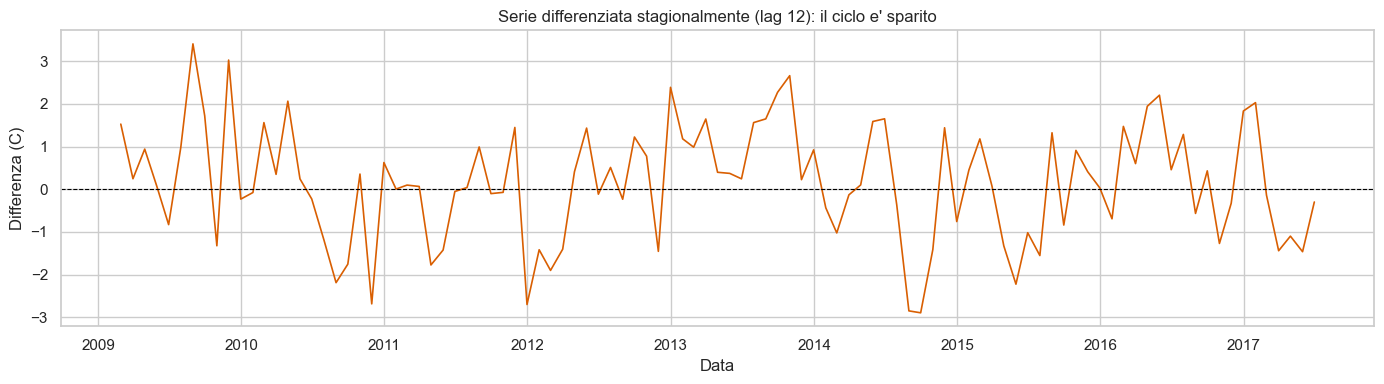

In [32]:
# differenziazione stagionale: valore del mese - valore dello stesso mese dell'anno prima
serie_d12 = serie.diff(12).dropna()
test_stazionarieta(serie_d12, "Dopo differenziazione stagionale (D=1, s=12)")

plt.figure(figsize=(14, 4))
plt.plot(serie_d12.index, serie_d12.values, color="#D95F02", lw=1.2)
plt.axhline(0, color="black", lw=.8, ls="--")
plt.title("Serie differenziata stagionalmente (lag 12): il ciclo e' sparito")
plt.xlabel("Data"); plt.ylabel("Differenza (C)")
plt.tight_layout(); plt.show()

## Identificazione degli ordini con ACF e PACF

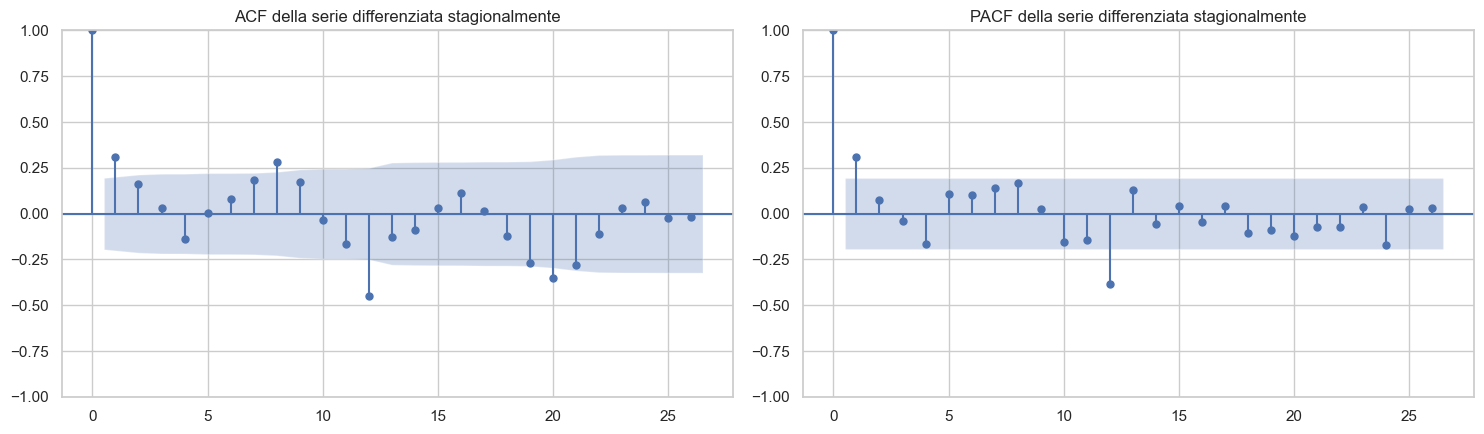

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_acf(serie_d12, lags=26, ax=axes[0])
axes[0].set_title("ACF della serie differenziata stagionalmente")
plot_pacf(serie_d12, lags=26, ax=axes[1], method="ywm")
axes[1].set_title("PACF della serie differenziata stagionalmente")
plt.tight_layout(); plt.show()

### Lettura dei grafici e ordini scelti

- **PACF** che si tronca dopo il lag 1 → componente **AR(1)** non stagionale → `p = 1`.
- Serie resa stazionaria dalla **differenziazione stagionale** a lag 12 → `D = 1`, `s = 12`.
- Picco stagionale nell'**ACF** al lag 12 → componente **SMA(1)** stagionale → `Q = 1`.
- Nessuna evidenza di differenziazione non stagionale → `d = 0`.

Ordini di partenza: **SARIMA (1,0,0)(0,1,1,12)**.

In [34]:
# DEFINIZIONE DEL MODELLO MANUALE DI PARTENZA (da ACF/PACF)
ORDER_MANUALE  = (1, 0, 0)      # (p, d, q)  -> AR(1)
SORDER_MANUALE = (0, 1, 1, 12)  # (P, D, Q, s) -> differenziazione stagionale + SMA(1)
print("Modello manuale (da ACF/PACF): SARIMAX", ORDER_MANUALE, SORDER_MANUALE)

Modello manuale (da ACF/PACF): SARIMAX (1, 0, 0) (0, 1, 1, 12)


## Validazione: split temporale

Train: 89 mesi (2008-02-29 -> 2015-06-30)
Test : 24 mesi (2015-07-31 -> 2017-06-30)


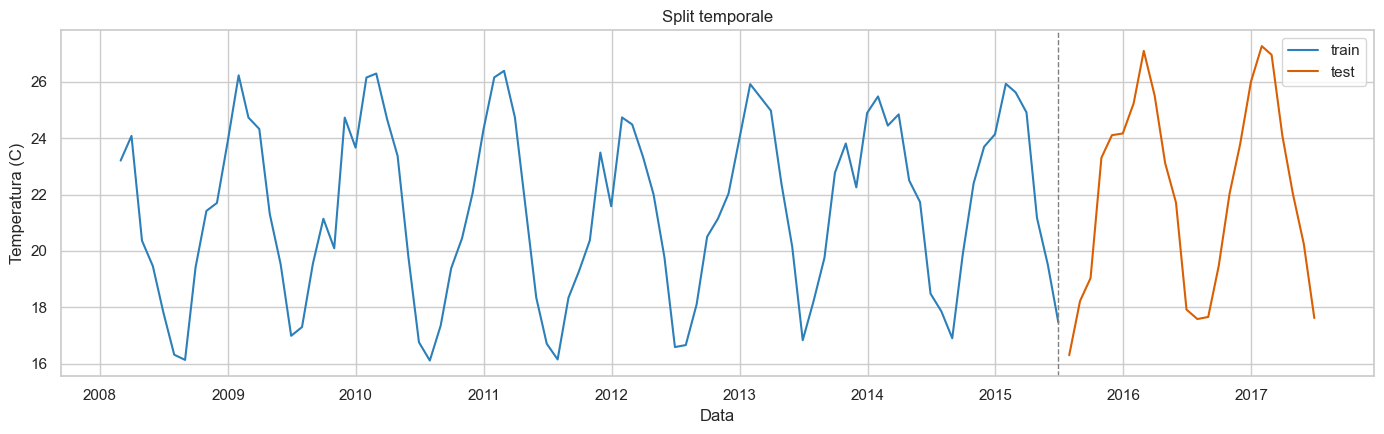

In [35]:
train, test = serie[:-N_TEST], serie[-N_TEST:]

print(f"Train: {len(train)} mesi ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} mesi ({test.index.min().date()} -> {test.index.max().date()})")

plt.figure(figsize=(14, 4.5))
plt.plot(train.index, train.values, label="train", color="#2C7FB8")
plt.plot(test.index, test.values, label="test", color="#D95F02")
plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title("Split temporale")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); plt.show()

## Modellazione

### SARIMAX manuale

In [36]:
# NOTA: lascio attivi i vincoli di default (enforce_stationarity/invertibility = True)
candidati = [
    ((1, 0, 0), (0, 1, 1, 12)),   # <- proposto da ACF/PACF
    ((0, 0, 1), (0, 1, 1, 12)),
    ((1, 0, 1), (0, 1, 1, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((2, 0, 0), (1, 1, 1, 12)),
    ((1, 0, 1), (1, 1, 0, 12)),
]

righe = []
for order, sorder in candidati:
    m = SARIMAX(train, order=order, seasonal_order=sorder).fit(disp=False)
    righe.append({"order": str(order), "seasonal_order": str(sorder),
                  "AIC": round(m.aic, 1), "BIC": round(m.bic, 1)})

aic_df = pd.DataFrame(righe).sort_values("AIC")
print("Confronto dei candidati (calcolato sul solo training):")
aic_df

Confronto dei candidati (calcolato sul solo training):


,order,seasonal_order,AIC,BIC
0,"(1, 0, 0)","(0, 1, 1, 12)",238.6,245.6
2,"(1, 0, 1)","(0, 1, 1, 12)",238.8,248.2
1,"(0, 0, 1)","(0, 1, 1, 12)",240.7,247.7
4,"(2, 0, 0)","(1, 1, 1, 12)",241.2,253.0
5,"(1, 0, 1)","(1, 1, 0, 12)",245.1,254.5
3,"(1, 0, 0)","(1, 1, 0, 12)",246.1,253.1


In [37]:
# addestro il modello manuale scelto da ACF/PACF
sarimax_man = SARIMAX(train, order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)
print(sarimax_man.summary().tables[0])
print(sarimax_man.summary().tables[1])


theta_s = sarimax_man.params.get("ma.S.L12", np.nan)
print(f"\nCoeff. MA stagionale (ma.S.L12) = {theta_s:+.3f} "
      f"-> vicino a -1 = bordo di invertibilità (SE inaffidabile)")

                                      SARIMAX Results                                       
Dep. Variable:                              Temp3pm   No. Observations:                   89
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -116.285
Date:                              Mon, 03 Aug 2026   AIC                            238.570
Time:                                      21:58:07   BIC                            245.601
Sample:                                  02-29-2008   HQIC                           241.383
                                       - 06-30-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3510      0.096      3.674      0.000       0.164       0.538
ma.S.L12      -0.99

### Selezione automatica degli ordini (grid search)

In [38]:
# Selezione automatica degli ordini: grid search per AIC 
import itertools

D, s = 1, 12
griglia = itertools.product(range(0, 3), range(0, 3), range(0, 2), range(0, 2))  # p, q, P, Q

best_aic, best_cfg, auto_model = np.inf, None, None
for p, q, P, Q in griglia:
    order, sorder = (p, 0, q), (P, D, Q, s)
    try:
        m = SARIMAX(train, order=order, seasonal_order=sorder).fit(disp=False)
        if np.isfinite(m.aic) and m.aic < best_aic:
            best_aic, best_cfg, auto_model = m.aic, (order, sorder), m
    except Exception:
        continue

HAS_AUTO = auto_model is not None
if HAS_AUTO:
    AUTO_ORDER, AUTO_SORDER = best_cfg
    print("Auto (grid search) -> ordini scelti:", AUTO_ORDER, AUTO_SORDER, f"| AIC={best_aic:.1f}")
    print(auto_model.summary().tables[0])
else:
    print("Nessun modello valido trovato nella griglia.")

Auto (grid search) -> ordini scelti: (1, 0, 0) (0, 1, 1, 12) | AIC=238.6
                                      SARIMAX Results                                       
Dep. Variable:                              Temp3pm   No. Observations:                   89
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -116.285
Date:                              Mon, 03 Aug 2026   AIC                            238.570
Time:                                      21:58:21   BIC                            245.601
Sample:                                  02-29-2008   HQIC                           241.383
                                       - 06-30-2015                                         
Covariance Type:                                opg                                         


### SARIMAX con variabili esogene

Aggiungiamo `Humidity3pm` e `Pressure3pm` come regressori esterni (la parte "X" di SARIMAX).

In [39]:
# Selezione e preparazione delle variabili esogene
EXOG_VARS = ["Humidity3pm", "Pressure3pm"]

# Esogene mensili per la stessa località, allineate all'indice di 'serie'
exog_mensile = (df[df["Location"] == LOCALITA]
                .set_index("Date")[EXOG_VARS].sort_index()
                .resample(FREQ).mean()
                .reindex(serie.index))

# Allineamento all'indice temporale e imputazione dei mancanti
exog_mensile = exog_mensile.reindex(serie.index).interpolate(method="time").bfill().ffill()

exog_train = exog_mensile.iloc[:-N_TEST].interpolate(method="time").ffill().bfill()
exog_test  = exog_mensile.iloc[-N_TEST:].interpolate(method="time").ffill().bfill()

# Addestro il modello sul train (le esogene di train sono valori realmente disponibili)
sarimax_exog = SARIMAX(train, exog=exog_train,
                       order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)

print("Coefficienti delle variabili esogene (p<0.05 = effetto significativo):")
print(sarimax_exog.summary().tables[1])

# Previsione ONESTA delle esogene: seasonal-naive stimato SOLO sul train 
# ripete gli ultimi 12 mesi di train lungo l'orizzonte e usa esclusivamente dati passati
exog_pred = pd.DataFrame(
    {c: np.resize(exog_train[c].values[-12:], N_TEST) for c in EXOG_VARS},
    index=test.index)

Coefficienti delle variabili esogene (p<0.05 = effetto significativo):
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Humidity3pm    -0.1109      0.026     -4.243      0.000      -0.162      -0.060
Pressure3pm     0.0345      0.043      0.806      0.420      -0.049       0.118
ar.L1           0.2665      0.133      1.997      0.046       0.005       0.528
ma.S.L12       -0.9984     49.211     -0.020      0.984     -97.451      95.454
sigma2          0.6634     32.596      0.020      0.984     -63.223      64.550


## Forecast e metriche di errore

In [40]:
def metriche(nome, reale, pred):
    mae  = mean_absolute_error(reale, pred)
    rmse = np.sqrt(mean_squared_error(reale, pred))
    # NB: la MAPE su gradi Celsius è poco significativa (lo zero della scala è arbitrario):
    #     si usano MAE/RMSE come metriche principali; la MAPE è solo indicativa.
    mape = np.mean(np.abs((reale - pred) / reale)) * 100
    return {"Modello": nome, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "MAPE %": round(mape, 2)}

# SARIMAX univariato: previsione a 24 passi, nessuna informazione dal test
fc_man   = sarimax_man.get_forecast(steps=N_TEST)
pred_man = fc_man.predicted_mean
ci_man   = fc_man.conf_int()

risultati = [metriche(f"SARIMAX manuale {ORDER_MANUALE}{SORDER_MANUALE}", test, pred_man)]

# auto-ARIMA (se disponibile)
if HAS_AUTO:
    pred_auto = auto_model.get_forecast(steps=N_TEST).predicted_mean
    risultati.append(metriche(f"auto (grid search) {AUTO_ORDER}{AUTO_SORDER}",
                              test, pred_auto))

# baseline seasonal-naive ONESTA a 24 passi:
# ripete gli ultimi 12 mesi di TRAIN lungo tutto l'orizzonte (nessun dato di test usato)
pred_naive = pd.Series(np.resize(train.values[-12:], N_TEST), index=test.index)
risultati.append(metriche("Baseline naive stagionale", test, pred_naive))

res_df = pd.DataFrame(risultati).sort_values("MAE")
res_df

,Modello,MAE,RMSE,MAPE %
2,Baseline naive stagionale,0.893,1.074,4.06
0,"SARIMAX manuale (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37
1,"auto (grid search) (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37


,MAE,RMSE,MAPE %
Modello,,,
"SARIMAX + esogene (oracolo) ['Humidity3pm', 'Pressure3pm']",0.727,0.863,3.24
Baseline naive stagionale,0.893,1.074,4.06
"auto (grid search) (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37
"SARIMAX manuale (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37
"SARIMAX + esogene (previste) ['Humidity3pm', 'Pressure3pm']",1.023,1.221,4.56


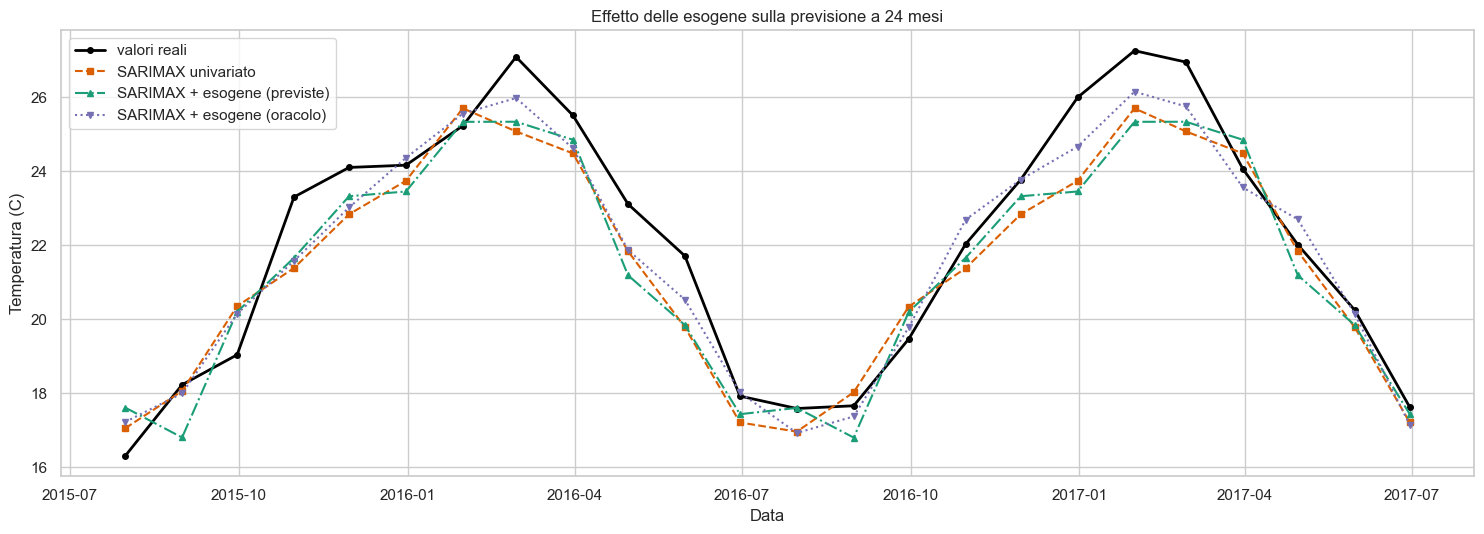

In [41]:
# Scenario 1: esogene PREVISTE (previsione ONESTA, senza lookahead) 
fc_exog_pred = sarimax_exog.get_forecast(steps=N_TEST, exog=exog_pred)
pred_exog_hon = fc_exog_pred.predicted_mean

# Scenario 2: esogene NOTE (ORACOLO: limite superiore, NON una previsione reale) 
fc_exog_true = sarimax_exog.get_forecast(steps=N_TEST, exog=exog_test)
pred_exog_ora = fc_exog_true.predicted_mean

risultati_completo = risultati + [
    metriche(f"SARIMAX + esogene (previste) {EXOG_VARS}", test, pred_exog_hon),
    metriche(f"SARIMAX + esogene (oracolo)  {EXOG_VARS}", test, pred_exog_ora),
]
display(pd.DataFrame(risultati_completo).set_index("Modello").sort_values("MAE"))

# GRAFICO COMPARATIVO TRA REALE E PREVISIONI SUL TEST SET
plt.figure(figsize=(15, 5.5))
plt.plot(test.index, test.values, label="valori reali", color="black", lw=2, marker="o", ms=4)
plt.plot(test.index, pred_man, label="SARIMAX univariato", color="#D95F02", ls="--", marker="s", ms=4)
plt.plot(test.index, pred_exog_hon, label="SARIMAX + esogene (previste)", color="#1B9E77", ls="-.", marker="^", ms=4)
plt.plot(test.index, pred_exog_ora, label="SARIMAX + esogene (oracolo)", color="#7570B3", ls=":", marker="v", ms=4)
plt.title(f"Effetto delle esogene sulla previsione a {N_TEST} mesi")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); plt.show()

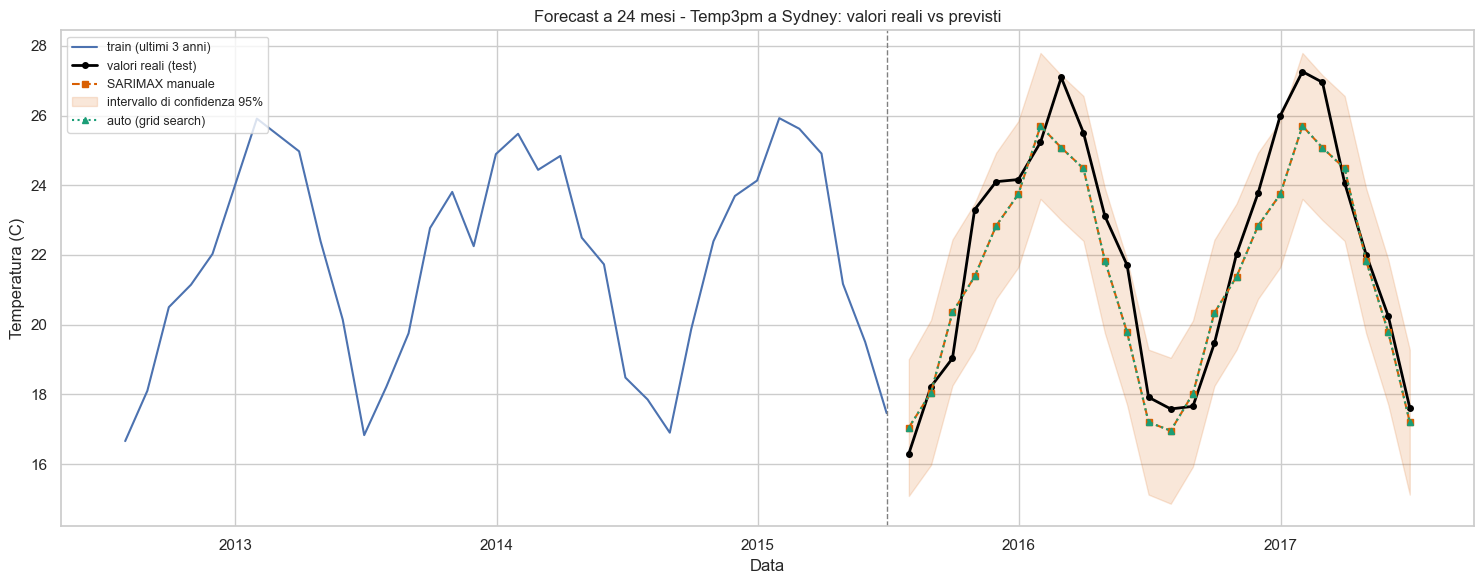

In [42]:
plt.figure(figsize=(15, 6))

# ultimi 36 mesi di train per contestualizzare la partenza della curva
plt.plot(train.index[-36:], train.values[-36:], label="train (ultimi 3 anni)", color="#4C72B0")
# dati reali sul test set
plt.plot(test.index, test.values, label="valori reali (test)", color="black", lw=2, marker="o", ms=4)
# previsione puntuale del SARIMAX manuale
plt.plot(test.index, pred_man, label="SARIMAX manuale", color="#D95F02", ls="--", marker="s", ms=4)
# intervallo di confidenza al 95%
plt.fill_between(test.index, ci_man.iloc[:, 0], ci_man.iloc[:, 1],
                 color="#D95F02", alpha=.15, label="intervallo di confidenza 95%")
# eventuale curva auto-ARIMA
if HAS_AUTO:
    plt.plot(test.index, pred_auto, label="auto (grid search)", color="#1B9E77", ls=":", marker="^", ms=4)

plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Forecast a {N_TEST} mesi - {VARIABILE} a {LOCALITA}: valori reali vs previsti")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

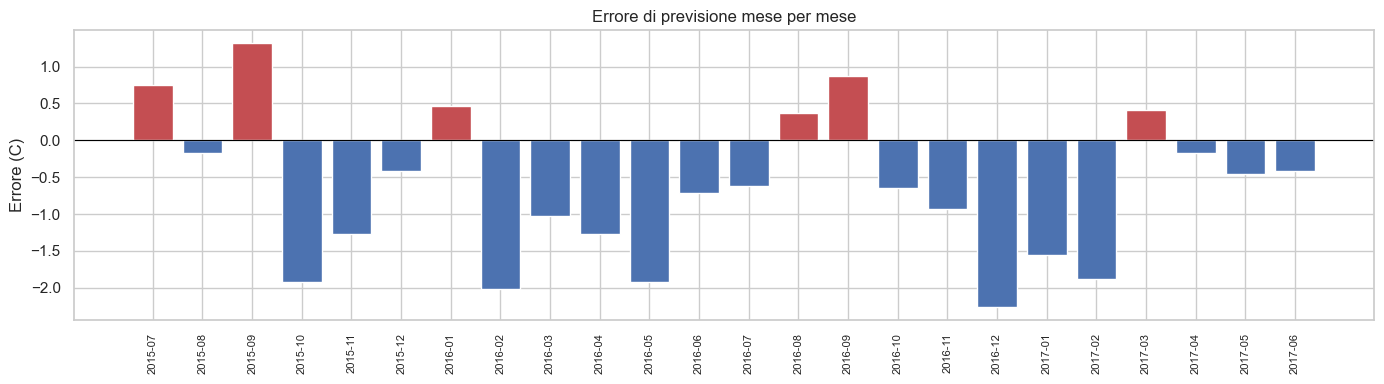

Errore medio (bias): -0.646 C
Errore massimo:      2.255 C


In [43]:
# errore mese per mese per vederedove sbaglia di piu' il modello
errori = pd.DataFrame({"reale": test, "previsto": pred_man})
errori["errore"] = errori["previsto"] - errori["reale"]

plt.figure(figsize=(14, 4))
colori = ["#C44E52" if e > 0 else "#4C72B0" for e in errori["errore"]]
plt.bar(range(len(errori)), errori["errore"], color=colori)
plt.axhline(0, color="black", lw=.8)
plt.xticks(range(len(errori)), [d.strftime("%Y-%m") for d in errori.index], rotation=90, fontsize=8)
plt.title("Errore di previsione mese per mese")
plt.ylabel("Errore (C)")
plt.tight_layout(); plt.show()

print(f"Errore medio (bias): {errori['errore'].mean():+.3f} C")
print(f"Errore massimo:      {errori['errore'].abs().max():.3f} C")

## Diagnostica dei residui

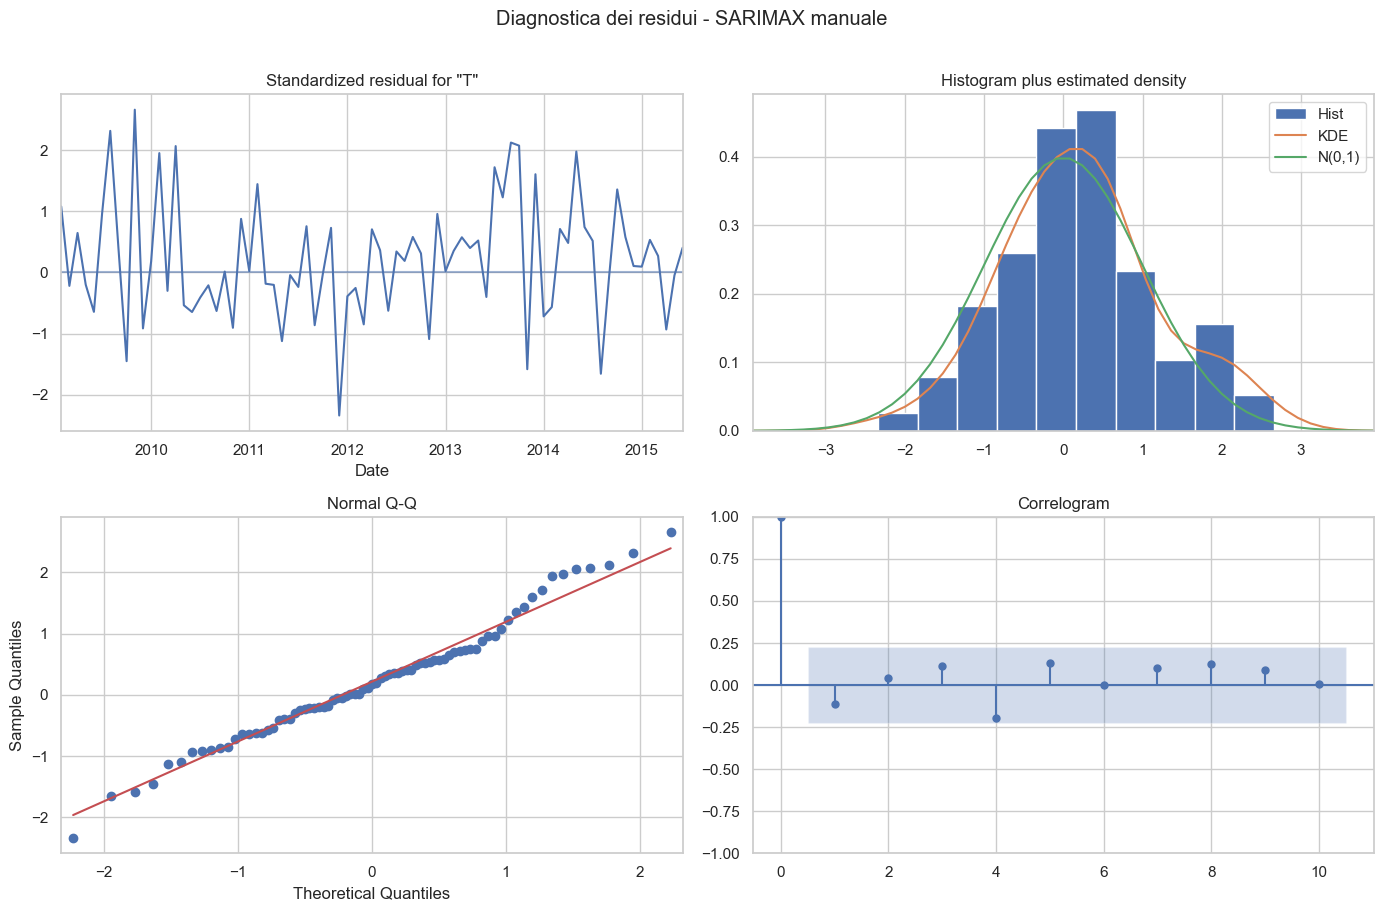

In [44]:
sarimax_man.plot_diagnostics(figsize=(14, 9))
plt.suptitle("Diagnostica dei residui - SARIMAX manuale", y=1.01)
plt.tight_layout(); plt.show()

In [45]:
SKIP = 12   # mesi di inizializzazione della differenziazione stagionale (residui non affidabili)
resid = sarimax_man.resid[SKIP:]

# gradi di libertà del modello = n. parametri ARMA stimati (esclusa sigma2), 
# usati per correggere i gradi di libertà del test di Ljung-Box
k_arma = sum(1 for n in sarimax_man.params.index if n != "sigma2")

lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], model_df=k_arma, return_df=True)
print(f"Test di Ljung-Box (H0: residui indipendenti -> vogliamo p > 0.05)  [model_df={k_arma}]:")
print(lb.round(4).to_string())

print(f"\nMedia dei residui: {resid.mean():+.3f} (attesa ~0)")
print(f"Deviazione standard: {resid.std():.3f}")

# controprova: cosa succederebbe SENZA scartare i primi 12 (errore da evitare)
lb_sbagliato = acorr_ljungbox(sarimax_man.resid, lags=[12], model_df=k_arma, return_df=True)
print(f"\n[Controprova] Ljung-Box sui residui grezzi -> p = {lb_sbagliato['lb_pvalue'].iloc[0]:.4f}")

Test di Ljung-Box (H0: residui indipendenti -> vogliamo p > 0.05)  [model_df=2]:
    lb_stat  lb_pvalue
6    7.4964     0.1119
12  10.7555     0.3769
18  11.3657     0.7864
24  17.1543     0.7548

Media dei residui: +0.242 (attesa ~0)
Deviazione standard: 1.112

[Controprova] Ljung-Box sui residui grezzi -> p = 0.0000


## Previsione futura

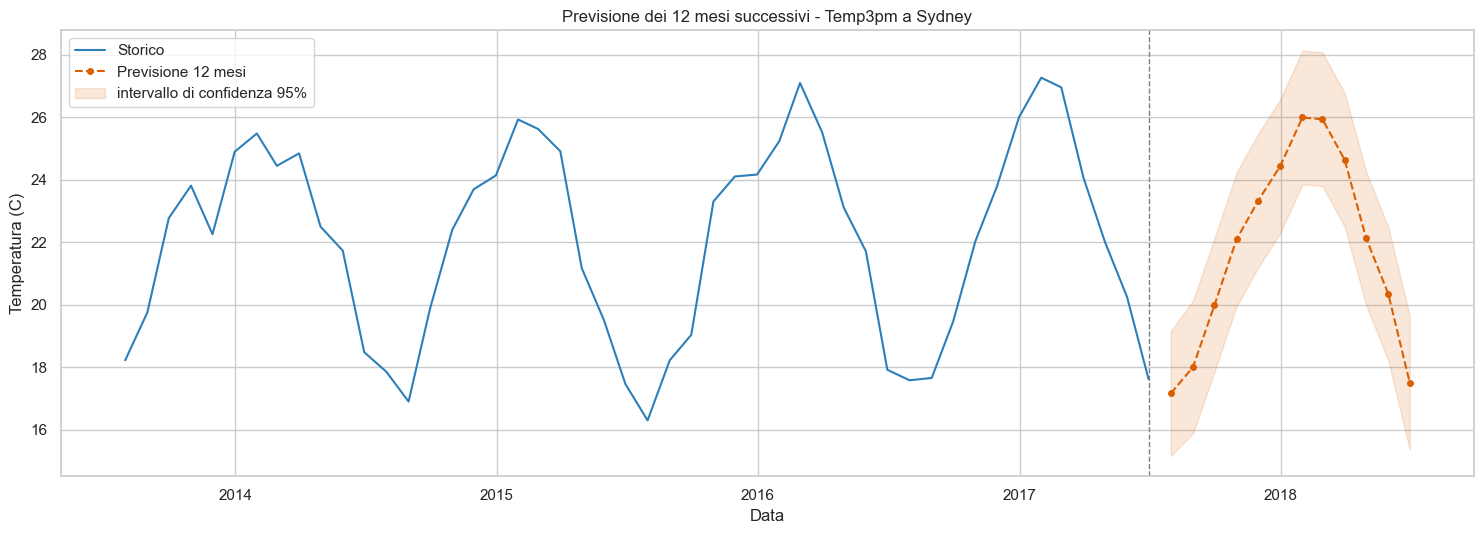

Previsione dei prossimi 12 mesi (C):
            previsione  IC 95% inf  IC 95% sup
2017-07-31        17.2        15.2        19.2
2017-08-31        18.0        15.9        20.1
2017-09-30        20.0        17.8        22.1
2017-10-31        22.1        20.0        24.2
2017-11-30        23.3        21.2        25.5
2017-12-31        24.4        22.3        26.6
2018-01-31        26.0        23.8        28.1
2018-02-28        25.9        23.8        28.1
2018-03-31        24.6        22.5        26.8
2018-04-30        22.1        20.0        24.3
2018-05-31        20.3        18.2        22.5
2018-06-30        17.5        15.4        19.6


In [46]:
# Modello definitivo su TUTTA la serie storica disponibile.
modello_finale = SARIMAX(serie, order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)

# forecast per i 12 mesi futuri oltre la fine del dataset
fc_fut   = modello_finale.get_forecast(steps=12)
pred_fut = fc_fut.predicted_mean
ci_fut   = fc_fut.conf_int()

plt.figure(figsize=(15, 5.5))
plt.plot(serie.index[-48:], serie.values[-48:], label="Storico", color="#2C7FB8")
plt.plot(pred_fut.index, pred_fut.values, label="Previsione 12 mesi", color="#D95F02",
         ls="--", marker="o", ms=4)
plt.fill_between(pred_fut.index, ci_fut.iloc[:, 0], ci_fut.iloc[:, 1],
                 color="#D95F02", alpha=.15, label="intervallo di confidenza 95%")
plt.axvline(serie.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Previsione dei 12 mesi successivi - {VARIABILE} a {LOCALITA}")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); plt.show()

print("Previsione dei prossimi 12 mesi (C):")
print(pd.DataFrame({"previsione": pred_fut.round(1),
                    "IC 95% inf": ci_fut.iloc[:, 0].round(1),
                    "IC 95% sup": ci_fut.iloc[:, 1].round(1)}).to_string())